In [ ]:
# Train/Test Split + Model Training


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("house_price_cleaned.csv")
print(df.shape)
df.head()

(5000, 11)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PriceTarget,region_NORTH,region_SOUTH
0,2.96,23,6.38,1.48,1580.0,1.83,41.109,-116.220,0.823,True,False
1,2.36,2,6.97,1.18,3910.0,5.38,37.375,-114.262,0.200,False,False
2,4.01,16,5.06,1.31,1068.0,3.45,34.645,-121.183,0.200,False,True
3,7.05,20,9.35,1.99,2399.0,2.79,41.177,-115.147,4.855,True,False
4,5.66,51,8.99,2.04,1930.0,1.40,34.742,-114.602,2.231,False,True


In [2]:
# Outlier decision (carried over from Day 2)

print("Before cap, max AveRooms:", df["AveRooms"].max())
df["AveRooms"] = df["AveRooms"].clip(upper=15)
print("After cap, max AveRooms:", df["AveRooms"].max())

Before cap, max AveRooms: 39.66992169668045
After cap, max AveRooms: 15.0


In [3]:
# Separate features (X) and target (y)

X = df.drop(columns=["PriceTarget"])
y = df["PriceTarget"]

print("Features:", list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'region_NORTH', 'region_SOUTH']
X shape: (5000, 10) | y shape: (5000,)


In [4]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (4000, 10)
Test size : (1000, 10)


In [5]:
# Feature scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # transform only on test

print("Train mean (should be ~0):", X_train_scaled.mean(axis=0).round(2))
print("Train std  (should be ~1):", X_train_scaled.std(axis=0).round(2))

Train mean (should be ~0): [-0. -0. -0.  0. -0.  0.  0. -0. -0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
# Train the model

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Training complete.")

Training complete.


In [7]:
# Extract and interpret coefficients

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("Intercept (b):", model.intercept_)
coef_df

Intercept (b): 1.6182132500000002


,feature,coefficient
0,MedInc,1.017038
5,AveOccup,-0.179722
1,HouseAge,-0.096921
9,region_SOUTH,-0.030171
2,AveRooms,0.027393
6,Latitude,-0.017459
7,Longitude,0.014384
8,region_NORTH,-0.012419
4,Population,0.007720
3,AveBedrms,0.003707


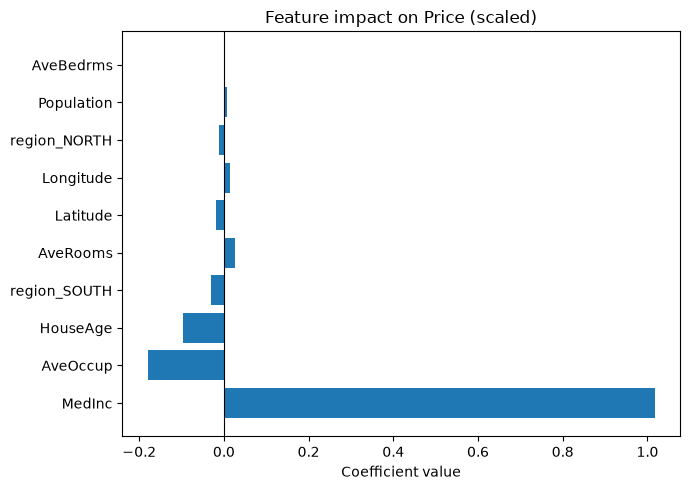

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.xlabel("Coefficient value")
plt.title("Feature impact on Price (scaled)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [9]:
# Quick check: predictions look sane?

y_pred_train = model.predict(X_train_scaled)

preview = pd.DataFrame({
    "actual": y_train.values[:10],
    "predicted": y_pred_train[:10].round(3)
})
preview

,actual,predicted
0,2.992,1.819
1,2.764,2.550
2,2.263,0.968
3,2.061,1.913
4,0.200,0.780
5,0.200,0.900
6,0.200,0.644
7,1.046,0.779
8,2.713,1.846
9,5.000,2.376


In [10]:
# Save everything needed for Day 4
import joblib

joblib.dump(model, "day3_model.pkl")
joblib.dump(scaler, "day3_scaler.pkl")
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled_df.to_csv("X_train_scaled.csv", index=False)
X_test_scaled_df.to_csv("X_test_scaled.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Saved model, scaler, and train/test splits for Day 4.")

Saved model, scaler, and train/test splits for Day 4.
